# Детекция номеров (YOLO + Roboflow + SVHN)


Перед запуском необходимо передать api-ключ `ROBOFLOW_API_KEY`


In [1]:
%pip -q install ultralytics roboflow pyyaml opencv-python matplotlib python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import Union

import cv2
import torch
from roboflow import Roboflow
from ultralytics import YOLO

torch.backends.cudnn.benchmark = True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
SEED = 555
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def get_device():
    if torch.cuda.is_available():
        return 0
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()

DEVICE

0

In [5]:
@dataclass
class RFSpec:
    workspace: str
    project: str
    version: int


def rf_download(spec: RFSpec, api_key: str, model_format: str = "yolov8") -> Path:
    rf = Roboflow(api_key=api_key)
    project = rf.workspace(spec.workspace).project(spec.project)
    ds = project.version(spec.version).download(model_format)
    return Path(ds.location)


def _find_data_yaml(dataset_dir: Path) -> Path:
    candidates = list(dataset_dir.rglob("data.yaml"))
    if not candidates:
        raise FileNotFoundError(f"data.yaml not found in {dataset_dir}")
    return sorted(candidates, key=lambda p: (len(p.parts), len(str(p))))[0]


def load_yaml(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def save_yaml(path: Path, data):
    with open(path, "w", encoding="utf-8") as f:
        yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)


def resolve_split_dir(data_yaml: Path, split: str) -> Path:
    key_map = {"train": "train", "val": "valid", "valid": "valid", "test": "test"}
    key = key_map[split]
    return (data_yaml.parent / key / "images").resolve()


def iter_label_files(data_yaml: Path):
    root = data_yaml.parent
    for split in ("train", "valid", "test"):
        lbl_dir = root / split / "labels"
        if lbl_dir.exists():
            for p in sorted(lbl_dir.glob("*.txt")):
                yield p


def to_single_class(data_yaml: Path, class_name: str = "number"):
    data = load_yaml(data_yaml)
    data["nc"] = 1
    data["names"] = [class_name]
    save_yaml(data_yaml, data)


def rewrite_to_single_class(data_yaml: Path, collapse_per_image: bool = False):
    for lbl_path in iter_label_files(data_yaml):
        with open(lbl_path, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f if ln.strip()]

        if not lines:
            lbl_path.write_text("", encoding="utf-8")
            continue

        rows = []
        for ln in lines:
            parts = ln.split()
            if len(parts) < 5:
                continue
            _, x, y, w, h = parts[:5]
            rows.append([float(x), float(y), float(w), float(h)])

        if not rows:
            lbl_path.write_text("", encoding="utf-8")
            continue

        arr = np.asarray(rows, dtype=np.float32)

        if collapse_per_image:
            # convert each bbox from YOLO format
            x1 = arr[:, 0] - arr[:, 2] / 2
            y1 = arr[:, 1] - arr[:, 3] / 2
            x2 = arr[:, 0] + arr[:, 2] / 2
            y2 = arr[:, 1] + arr[:, 3] / 2
            # take the minimum common bbox
            ux1, uy1 = np.clip([x1.min(), y1.min()], 0.0, 1.0)
            ux2, uy2 = np.clip([x2.max(), y2.max()], 0.0, 1.0)
            # convert back
            cx = (ux1 + ux2) / 2
            cy = (uy1 + uy2) / 2
            w = ux2 - ux1
            h = uy2 - uy1
            lines_out = [f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n"]
        else:
            lines_out = [f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n" for x, y, w, h in arr]

        with open(lbl_path, "w", encoding="utf-8") as f:
            f.writelines(lines_out)

    to_single_class(data_yaml)

In [6]:
ROOT = Path("/content/drive/MyDrive/runs_number_detection")
ROOT.mkdir(parents=True, exist_ok=True)

from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY") or ""

SVHN_SPEC = RFSpec(workspace="liza-tvgyc", project="svhn-yolo-z3o4t-net6y", version=2)

PRETRAIN_SPEC = RFSpec(workspace="university-of-toronto-xho85", project="numberdetection-eppfj", version=2)

SVHN_COLLAPSE_TO_ONE_BOX = True  # merge all digit boxes in image into one "number" box
PRETRAIN_COLLAPSE_TO_ONE_BOX = False

IMGSZ = 640
BATCH = 32
EPOCHS_PRETRAIN = 40
EPOCHS_FINETUNE = 60
MODEL_BASE = "yolov8n.pt"
CONF_THRES = 0.25

In [7]:
# Download datasets
svhn_dir = rf_download(SVHN_SPEC, ROBOFLOW_API_KEY, model_format="yolov8")
pre_dir = rf_download(PRETRAIN_SPEC, ROBOFLOW_API_KEY, model_format="yolov8")

svhn_yaml = _find_data_yaml(svhn_dir)
pre_yaml = _find_data_yaml(pre_dir)

print("SVHN:", svhn_yaml)
print("PRETRAIN:", pre_yaml)

# Normalize labels to a single class 'number'
rewrite_to_single_class(svhn_yaml, collapse_per_image=SVHN_COLLAPSE_TO_ONE_BOX)

for cache_path in [*svhn_dir.rglob("*.cache"), *pre_dir.rglob("*.cache")]:
    cache_path.unlink(missing_ok=True)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to SVHN-YOLO-2 in yolov8:: 100%|██████████| 3512/3512 [00:00<00:00, 10761.35it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to numberdetection-2 in yolov8:: 100%|██████████| 2374/2374 [00:00<00:00, 5343.17it/s]


SVHN: /content/SVHN-YOLO-2/data.yaml
PRETRAIN: /content/numberdetection-2/data.yaml


In [8]:
def train_detector(model_weights: Union[str, Path], data_yaml: Path, name: str, epochs: int):
    save_dir = ROOT / name
    best_existing = save_dir / "weights" / "best.pt"
    if best_existing.exists():
        print(f"Using existing trained model: {best_existing}")
        return save_dir, best_existing

    model = YOLO(str(model_weights))
    result = model.train(
        data=str(data_yaml),
        task="detect",
        imgsz=IMGSZ,
        epochs=epochs,
        batch=BATCH,
        device=DEVICE,
        workers=4,
        cos_lr=True,
        optimizer="auto",
        patience=20,
        seed=SEED,
        deterministic=False,
        cache=True,
        amp=True,
        plots=True,
        project=str(ROOT),
        name=name,
        exist_ok=True,
        verbose=True,
    )
    best = Path(result.save_dir) / "weights" / "best.pt"
    return Path(result.save_dir), best


_, stage1_best = train_detector(MODEL_BASE, pre_yaml, "pretrain_numberdetection", EPOCHS_PRETRAIN)
print("stage1_best:", stage1_best)

ft_dir, ft_best = train_detector(stage1_best, svhn_yaml, "finetune_svhn", EPOCHS_FINETUNE)
print("ft_best:", ft_best)

Using existing trained model: /content/drive/MyDrive/runs_number_detection/pretrain_numberdetection/weights/best.pt
stage1_best: /content/drive/MyDrive/runs_number_detection/pretrain_numberdetection/weights/best.pt
Using existing trained model: /content/drive/MyDrive/runs_number_detection/finetune_svhn/weights/best.pt
ft_best: /content/drive/MyDrive/runs_number_detection/finetune_svhn/weights/best.pt


In [9]:
def _img_files_from_dir(img_dir: Path):
    return sorted([p for p in img_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg"}])


def _label_path_for_image(img_path: Path) -> Path:
    if img_path.parent.name == "images":
        return img_path.parent.parent / "labels" / (img_path.stem + ".txt")
    s = str(img_path).replace("/images/", "/labels/")
    return Path(s).with_suffix(".txt")


def _read_yolo_boxes_xyxy(label_path: Path, img_w: int, img_h: int):
    if not label_path.exists():
        return np.zeros((0, 4), dtype=np.float32)
    rows = []
    with open(label_path, "r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parts = ln.split()
            if len(parts) < 5:
                continue
            _, x, y, w, h = parts[:5]
            x, y, w, h = map(float, (x, y, w, h))
            x1 = (x - w / 2) * img_w
            y1 = (y - h / 2) * img_h
            x2 = (x + w / 2) * img_w
            y2 = (y + h / 2) * img_h
            rows.append([x1, y1, x2, y2])
    return np.asarray(rows, dtype=np.float32) if rows else np.zeros((0, 4), dtype=np.float32)


def _box_iou_matrix(a: np.ndarray, b: np.ndarray):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=np.float32)
    tl = np.maximum(a[:, None, :2], b[None, :, :2])
    br = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(br - tl, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    area_a = np.clip(a[:, 2] - a[:, 0], 0, None) * np.clip(a[:, 3] - a[:, 1], 0, None)
    area_b = np.clip(b[:, 2] - b[:, 0], 0, None) * np.clip(b[:, 3] - b[:, 1], 0, None)
    union = area_a[:, None] + area_b[None, :] - inter + 1e-9
    return inter / union


def mean_iou_on_split(model: YOLO, data_yaml: Path, split: str = "test", conf: float = 0.25, match_iou: float = 0.5):
    img_dir = resolve_split_dir(data_yaml, split)
    img_files = _img_files_from_dir(img_dir)
    matched_ious = []
    total_gt, total_pred, total_tp = 0, 0, 0

    for img_path in img_files:
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        gt = _read_yolo_boxes_xyxy(_label_path_for_image(img_path), w, h)
        total_gt += len(gt)

        pred_res = model.predict(
            source=str(img_path),
            imgsz=IMGSZ,
            conf=conf,
            device=DEVICE,
            verbose=False,
            save=False,
            max_det=300,
        )[0]

        if pred_res.boxes is None or len(pred_res.boxes) == 0:
            continue

        pred = pred_res.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
        confs = pred_res.boxes.conf.detach().cpu().numpy().astype(np.float32)
        order = np.argsort(-confs)
        pred = pred[order]
        total_pred += len(pred)

        if len(gt) == 0:
            continue

        ious = _box_iou_matrix(pred, gt)
        used_gt = set()
        for pi in range(len(pred)):
            gi = int(np.argmax(ious[pi])) if ious.shape[1] else -1
            if gi < 0:
                continue
            iou = float(ious[pi, gi])
            if iou >= match_iou and gi not in used_gt:
                used_gt.add(gi)
                total_tp += 1
                matched_ious.append(iou)

    precision = total_tp / (total_pred + 1e-9)
    recall = total_tp / (total_gt + 1e-9)
    miou = float(np.mean(matched_ious)) if matched_ious else 0.0
    return {
        "images": len(img_files),
        "gt_boxes": int(total_gt),
        "pred_boxes": int(total_pred),
        f"tp@{match_iou:.2f}": int(total_tp),
        f"precision@{match_iou:.2f}": float(precision),
        f"recall@{match_iou:.2f}": float(recall),
        "mean_iou_matched": miou,
    }


best_model = YOLO(str(ft_best))

val_metrics = best_model.val(
    data=str(svhn_yaml),
    split="test",
    imgsz=IMGSZ,
    conf=CONF_THRES,
    device=DEVICE,
    plots=True,
    project=str(ROOT),
    name="val_svhn_test",
    exist_ok=True,
    verbose=True,
)

summary = {
    "precision": float(val_metrics.box.mp),
    "recall": float(val_metrics.box.mr),
    "mAP50": float(val_metrics.box.map50),
    "mAP50_95": float(val_metrics.box.map),
}
summary.update(mean_iou_on_split(best_model, svhn_yaml, split="test", conf=CONF_THRES, match_iou=0.5))

report_path = ROOT / "metrics_summary.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("File with metrics:", report_path.resolve())
print("Weights:", Path(ft_best).resolve())
print()

summary

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 562.1±174.7 MB/s, size: 19.7 KB)
val: Scanning /content/SVHN-YOLO-2/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.5Kit/s 0.1s
val: New cache created: /content/SVHN-YOLO-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.9it/s 3.7s
                   all        100        100      0.933       0.93      0.957        0.6
Speed: 4.5ms preprocess, 12.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/drive/MyDrive/runs_number_detection/val_svhn_test
File with metrics: /content/drive/MyDrive/runs_number_detection/metrics_summary.json
Weights: /content/drive/MyDrive/runs_number_detection/finetune_svhn/weights/best.pt



{'precision': 0.9327275438398379,
 'recall': 0.93,
 'mAP50': 0.9565024284695743,
 'mAP50_95': 0.6003238994947541,
 'images': 100,
 'gt_boxes': 100,
 'pred_boxes': 111,
 'tp@0.50': 93,
 'precision@0.50': 0.8378378378302898,
 'recall@0.50': 0.9299999999906999,
 'mean_iou_matched': 0.799746012174955}

In [10]:
def show_images(images, cols=3, figsize=(14, 8), titles=None):
    images = list(images)
    if not images:
        print("No images")
        return
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, im in enumerate(images, 1):
        plt.subplot(rows, cols, i)
        if isinstance(im, (str, Path)):
            arr = cv2.imread(str(im))
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
        else:
            arr = im
        plt.imshow(arr)
        plt.axis("off")
        if titles and i - 1 < len(titles):
            plt.title(titles[i - 1], fontsize=10)
    plt.tight_layout()
    plt.show()

Photo found: 8
Results saved to /content/drive/MyDrive/runs_number_detection/predict_special_photos


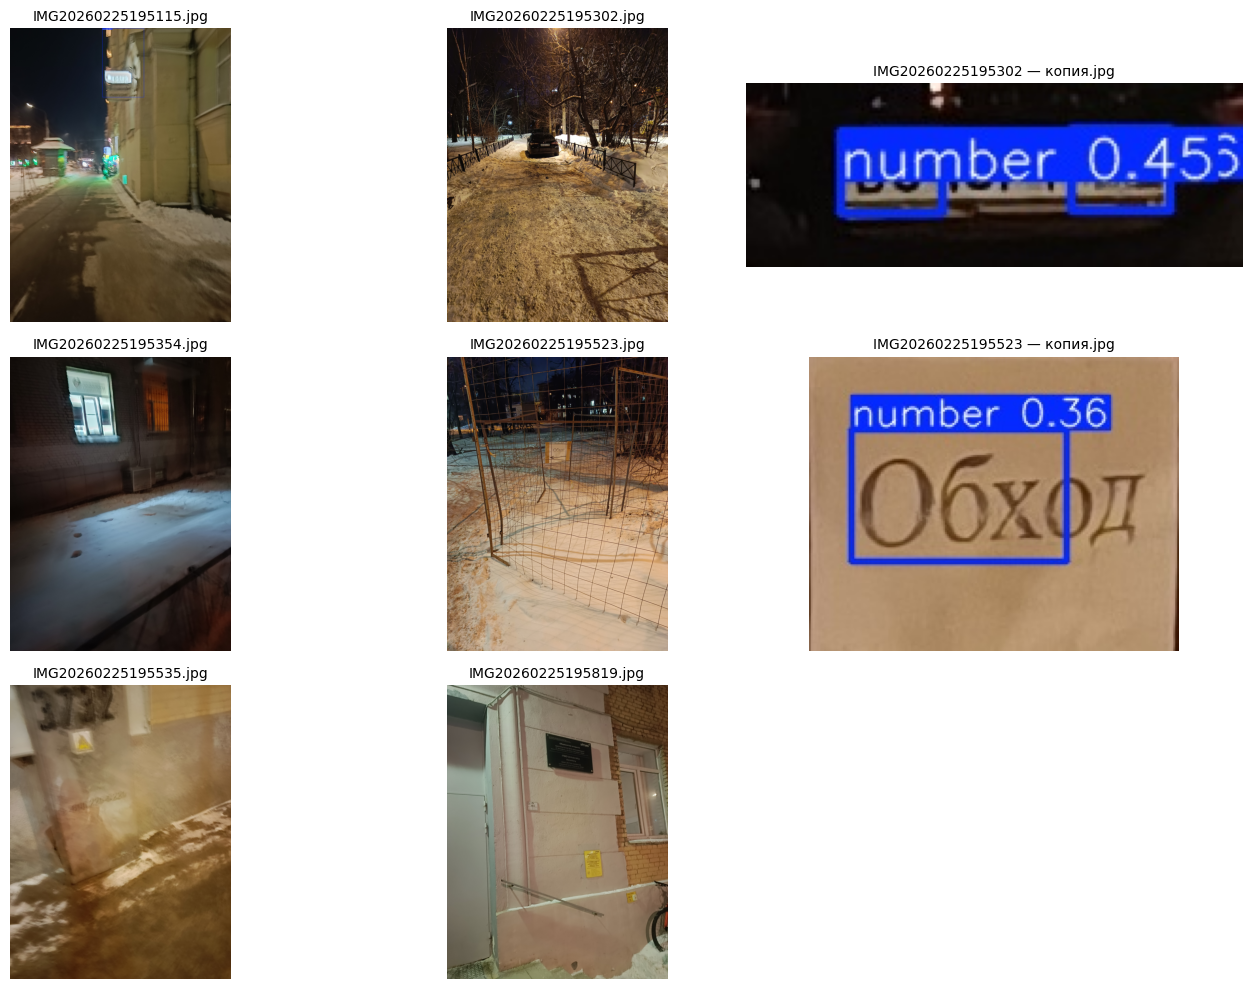

In [11]:
MY_PHOTOS_DIR = Path("/content/drive/MyDrive/computer_vision/special_photos")

user_imgs = [p for p in MY_PHOTOS_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg"}]
print("Photo found:", len(user_imgs))

if user_imgs:
    best_model.predict(
        source=str(MY_PHOTOS_DIR),
        imgsz=IMGSZ,
        conf=CONF_THRES,
        device=DEVICE,
        save=True,
        project=str(ROOT),
        name="predict_special_photos",
        exist_ok=True,
        line_width=2,
        verbose=False,
    )
    out_dir = ROOT / "predict_special_photos"
    out_imgs = [p for p in out_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg"}]
    out_imgs = sorted(out_imgs)
    show_images(out_imgs[:12], cols=3, figsize=(14, 10), titles=[p.name for p in out_imgs[:12]])
else:
    print(f"No files found in {MY_PHOTOS_DIR.resolve()}")

### Вывод

'mAP50_95' = 0.6003238994947541 => требование > 0.6 выполнено

На моих фото модель детектирует плохо. Это происходит из-за того, что модель обучалась на совсем не похожем датасете. Если вырезать нужные области, чтобы они были более похожими – детектировать получается лучше.